# Problem Title - Scratch Mode
Issue: #3

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


np.random.seed(42)

## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [2]:
df = pd.read_csv("../dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [3]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.196552
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.397421
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [4]:
df["quality_binary"].value_counts()

quality_binary
0    5220
1    1277
Name: count, dtype: int64

In [5]:
df["quality"].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [6]:
df = df.drop("quality", axis=1) #no need for this

In [7]:
df.corr()["quality_binary"].sort_values(ascending=False)

quality_binary          1.000000
alcohol                 0.390486
citric_acid             0.054444
sulphates               0.033971
pH                      0.028149
free_sulfur_dioxide     0.014767
fixed_acidity          -0.049447
total_sulfur_dioxide   -0.051226
residual_sugar         -0.063992
volatile_acidity       -0.151714
chlorides              -0.161781
density                -0.275441
Name: quality_binary, dtype: float64

In [8]:
shape = df.shape
(shape[0], shape[1])


(6497, 12)

## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [9]:
df = df.sample(frac=1).reset_index(drop=True)

df['alcohol_bin'] = pd.qcut(df['alcohol'], q=5, labels=False)
df['stratify_key'] = df['quality_binary'].astype(str) + "_" + df['alcohol_bin'].astype(str)

train_df = df.groupby('stratify_key', group_keys=False).apply(
    lambda x: x.sample(frac=0.80)
)

test_df = df.drop(train_df.index)

columns_to_drop = ['alcohol_bin', 'stratify_key']
train_df = train_df.drop(columns=columns_to_drop, errors="ignore")
test_df = test_df.drop(columns=columns_to_drop, errors="ignore")

In [10]:
features = [col for col in train_df.columns if col != 'quality_binary']

train_mean = train_df[features].mean()
train_std = train_df[features].std()

train_df[features] = (train_df[features] - train_mean) / train_std
test_df[features] = (test_df[features] - train_mean) / train_std

In [11]:
train_x = train_df.drop(columns="quality_binary")
train_y = train_df["quality_binary"]

In [12]:
test_x = test_df.drop(columns="quality_binary")
test_y = test_df["quality_binary"]

In [13]:
shape = train_x.shape
(shape[0], shape[1])

(5198, 11)

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [14]:
import numpy as np

def sigmoid(Z):
    
    A = 1/(1+np.exp(-Z))
    cache = Z
    
    return A, cache

def relu(Z):
  
    A = np.maximum(0,Z)
    
    assert(A.shape == Z.shape)
    
    cache = Z 
    return A, cache


def relu_backward(dA, cache):
    
    Z = cache
    dZ = np.array(dA, copy=True) 
    
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ

def sigmoid_backward(dA, cache):
    
    Z = cache
    
    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    
    assert (dZ.shape == Z.shape)
    
    return dZ



### 2 - layer Neural Network

the model's structure is (LINER -> RELU) --> (LINER -> SIGMOID)

In [15]:
def initialize_parameters(n_x, n_h, n_y):
   
    np.random.seed(1)
    
    W1 = np.random.randn(n_h,n_x) * np.sqrt(2/n_x)
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y,n_h) * np.sqrt(1/n_h)
    b2 = np.zeros((n_y,1))
    
    assert(W1.shape == (n_h, n_x))
    assert(b1.shape == (n_h, 1))
    assert(W2.shape == (n_y, n_h))
    assert(b2.shape == (n_y, 1))
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters    

In [16]:
def linear_forward(A, W, b):
   
    Z = np.dot(W,A) + b
    
    assert(Z.shape == (W.shape[0], A.shape[1]))
    cache = (A, W, b)
    
    return Z, cache

In [17]:
def linear_activation_forward(A_prev, W, b, activation):
    
    if activation == "sigmoid":
      
        Z, linear_cache = linear_forward(A_prev, W, b) 
        A, activation_cache = sigmoid(Z)
    
    elif activation == "relu":

        Z, linear_cache = linear_forward(A_prev, W, b) 
        A, activation_cache = relu(Z)
    
    assert (A.shape == (W.shape[0], A_prev.shape[1]))
    cache = (linear_cache, activation_cache)

    return A, cache

In [ ]:
def compute_cost(AL, Y):
   
    m = Y.shape[1]

    cost = (-1/m) * (np.dot(Y, np.log(AL).T) + np.dot((1-Y), np.log(1-AL).T))
   
    cost = np.squeeze(cost)      
    assert(cost.shape == ())
    
    return cost

In [19]:
def linear_backward(dZ, cache):
   
    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = (1/m) * np.dot(dZ, A_prev.T)
    db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T,dZ)
    
    assert (dA_prev.shape == A_prev.shape)
    assert (dW.shape == W.shape)
    assert (db.shape == b.shape)
    
    return dA_prev, dW, db

In [20]:
def linear_activation_backward(dA, cache, activation):
   
    linear_cache, activation_cache = cache
    
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    
    return dA_prev, dW, db

In [21]:
def update_parameters(parameters, grads, learning_rate):
    
    
    L = len(parameters) // 2

    for l in range(L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]

    return parameters

In [22]:
n_x = 11
n_h = 16
n_y = 1
layers_dims = (n_x, n_h, n_y)

In [34]:
def model(X_train, Y_train, X_test, Y_test, layers_dims, learning_rate=0.05, num_iterations=3000, print_cost=False):
    
    np.random.seed(1)
    grads = {}
    costs_train = []                           
    costs_test = []                           
    (n_x, n_h, n_y) = layers_dims

    parameters = initialize_parameters(n_x, n_h, n_y)
    
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    # Gradient Descent
    for i in range(0, num_iterations):
        
        A1, cache1 = linear_activation_forward(X_train, W1, b1, activation="relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, activation="sigmoid")
        cost_train = compute_cost(A2, Y_train)
        
  
        A1_test, _ = linear_activation_forward(X_test, W1, b1, activation="relu")
        A2_test, _ = linear_activation_forward(A1_test, W2, b2, activation="sigmoid")
        cost_test = compute_cost(A2_test, Y_test)
        
        A2_safe = np.clip(A2, 1e-15, 1 - 1e-15)
        dA2 = - (np.divide(Y_train, A2_safe) - np.divide(1 - Y_train, 1 - A2_safe))
        
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation="sigmoid")
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation="relu")
        
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2
        
        parameters = update_parameters(parameters, grads, learning_rate)

        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        
        if i % 50 == 0:
            costs_train.append(cost_train)
            costs_test.append(cost_test)
            if print_cost:
                print(f"Iteration {i:4d} | Train Cost: {cost_train:.5f} | Test Cost: {cost_test:.5f}")
       

    plt.plot(np.squeeze(costs_train), label='Train Cost', color='blue')
    plt.plot(np.squeeze(costs_test), label='Test Cost', color='red', linestyle='--')
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per 50)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.legend(loc='upper right')
    plt.show()
    
    return parameters

In [37]:
def predict(X, y, parameters):
    
    m = X.shape[1]
    
    A1, _ = linear_activation_forward(X, parameters["W1"], parameters["b1"], activation="relu")
    probas, _ = linear_activation_forward(A1, parameters["W2"], parameters["b2"], activation="sigmoid")
    
   
    p = (probas > 0.5).astype(int)
    

    accuracy = np.mean(p == y) * 100
    print(f"Accuracy: {accuracy:.2f}%")
        
    return p

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

Iteration    0 | Train Cost: 0.61898 | Test Cost: 0.60696
Iteration   50 | Train Cost: 0.41216 | Test Cost: 0.40917
Iteration  100 | Train Cost: 0.40092 | Test Cost: 0.40119
Iteration  150 | Train Cost: 0.39508 | Test Cost: 0.39711
Iteration  200 | Train Cost: 0.39089 | Test Cost: 0.39406
Iteration  250 | Train Cost: 0.38754 | Test Cost: 0.39152
Iteration  300 | Train Cost: 0.38475 | Test Cost: 0.38936
Iteration  350 | Train Cost: 0.38236 | Test Cost: 0.38749
Iteration  400 | Train Cost: 0.38029 | Test Cost: 0.38586
Iteration  450 | Train Cost: 0.37846 | Test Cost: 0.38445
Iteration  500 | Train Cost: 0.37683 | Test Cost: 0.38320
Iteration  550 | Train Cost: 0.37536 | Test Cost: 0.38210
Iteration  600 | Train Cost: 0.37402 | Test Cost: 0.38111
Iteration  650 | Train Cost: 0.37280 | Test Cost: 0.38023
Iteration  700 | Train Cost: 0.37168 | Test Cost: 0.37942
Iteration  750 | Train Cost: 0.37063 | Test Cost: 0.37869
Iteration  800 | Train Cost: 0.36965 | Test Cost: 0.37803
Iteration  850

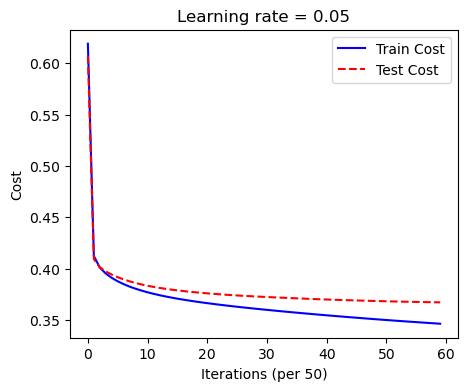

In [36]:
X_test_T = test_x.T
Y_test_2D = test_y.to_numpy().reshape(1, -1)
Y_train_2D = train_y.to_numpy().reshape(1, -1)

parameters = model(
    X_train=train_x.T, 
    Y_train=Y_train_2D, 
    X_test=X_test_T, 
    Y_test=Y_test_2D, 
    layers_dims=(n_x, 100, n_y), 
    num_iterations=3000, 
    print_cost=True, 
    learning_rate=0.05
)

## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

In [38]:
train_predictions = predict(train_x.T, Y_train_2D, parameters)
test_predictions = predict(X_test_T, Y_test_2D, parameters)

Accuracy: 83.57%
Accuracy: 82.76%


## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

### ANS

1. I already knew the math part and i had already done this so this was a good a revist for me
2. both test and train first decreased rapidly and then test began to hit a plateau and train will eventually become zero. i will try to experiment the double descent with this by setting n_h to 1000 and increasing the no. of iterations, i hope to see the test shoot up and go even below :) . 
3. that coding everything from scratch and solving the bugs really sucks(i used gemini for that)